# Supply Chain Risk Prediction: Model Evaluation
Generating predictions, plotting metrics, and exporting the final optimal model for the backend API.

In [1]:
# --- Setup, Load Data & Models ---
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

X_test = joblib.load('../data/test/X_test.pkl')
y_test = joblib.load('../data/test/y_test.pkl')
trained_models = joblib.load('../model/all_trained_models.pkl')
X_train_columns = joblib.load('../../optichain-backend/model/model_columns.pkl')

## Generate Predictions and Metrics
Extracting performance data for the trained classifiers.

In [2]:
# --- Generate Predictions & Metrics ---
results = {}
for name, model in trained_models.items():
    predictions   = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "model": model,
        "accuracy":  accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall":    recall_score(y_test, predictions),
        "f1":        f1_score(y_test, predictions),
        "roc_auc":   roc_auc_score(y_test, probabilities),
        "preds": predictions,
        "probs": probabilities
    }

results_table = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ["model", "preds", "probs"]}
    for name, r in results.items()
}).T

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON (%)")
print("=" * 80)
display((results_table * 100).round(2))

MODEL PERFORMANCE COMPARISON (%)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,68.96,83.03,54.32,65.67,74.27
Random Forest,70.83,84.62,56.98,68.10,77.11
XGBoost,70.13,80.18,60.23,68.79,77.03


## Visual Comparisons
Visualizing metric scores, confusion matrices, and ROC curves.

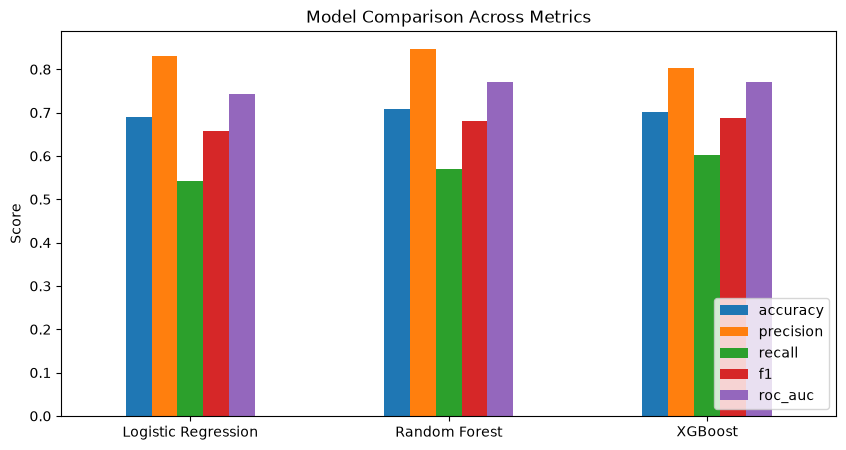

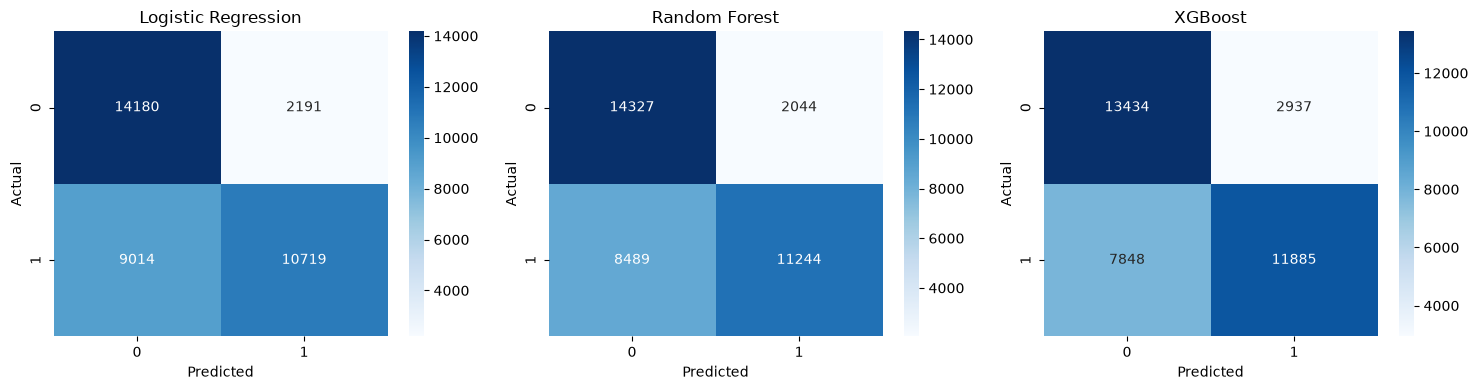

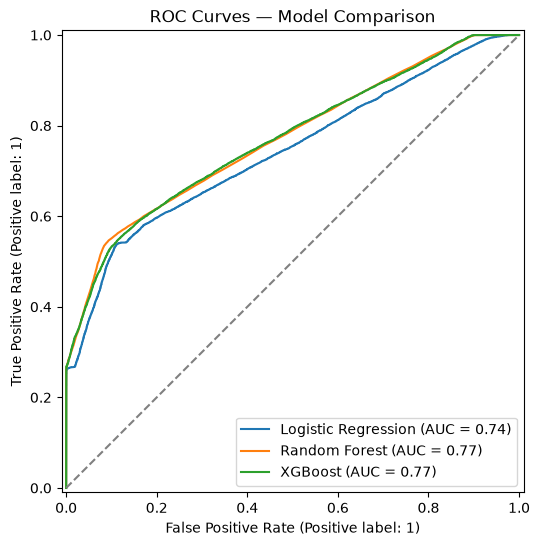

In [3]:
# --- Visual Comparisons ---
results_table[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, len(trained_models), figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    RocCurveDisplay.from_predictions(y_test, r["probs"], name=name, ax=ax)
plt.title("ROC Curves — Model Comparison")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

## Select and Save Final Model
Identifying the best model based on ROC-AUC and exporting it for production.

Best model based on ROC-AUC: Random Forest
              precision    recall  f1-score   support

           0       0.63      0.88      0.73     16371
           1       0.85      0.57      0.68     19733

    accuracy                           0.71     36104
   macro avg       0.74      0.72      0.71     36104
weighted avg       0.75      0.71      0.70     36104

Saved Random Forest as final late_delivery_model.pkl


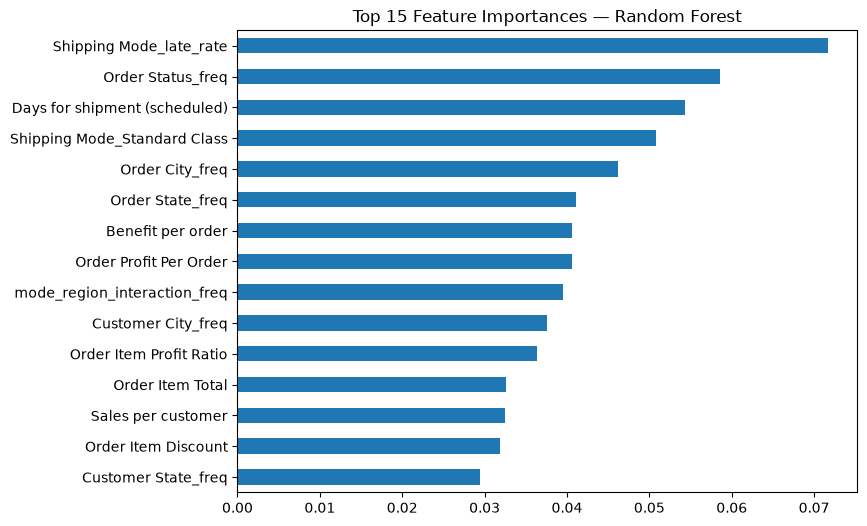

In [4]:
# --- Select & Save Best Model ---
best_model_name = results_table["roc_auc"].astype(float).idxmax()
best_model = results[best_model_name]["model"]

print(f"Best model based on ROC-AUC: {best_model_name}")
print(classification_report(y_test, results[best_model_name]["preds"]))

# Save the final singular best model as requested in the original script
joblib.dump(best_model, '../../optichain-backend/model/late_delivery_model.pkl')
print(f"Saved {best_model_name} as final late_delivery_model.pkl")

# --- Feature Importances ---
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train_columns)
    importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("The selected model doesn't expose feature importances (normal for Logistic Regression).")